# BigQuery Loader Demo

This notebook demonstrates `scripts/load_to_bigquery.py`: a second, independent
data path alongside the `macro_data` CSV store shown in `data_gathering_demo.ipynb`.
It fetches BOT, Yahoo Finance, and FRED series **directly from their APIs**
(bypassing the local CSV store entirely), transforms each series into a flat,
BigQuery-ready row shape, and truncate-reloads them into five category-specific
BigQuery staging tables: `fx`, `commodities`, `rates`, `equities`, `macro`.

The three phases are demonstrated **in order, as separate steps** -- get the
data from the sources first, then transform it, then push it to BigQuery --
mirroring exactly what `load_to_bigquery.run()` does internally, just with
every intermediate result inspectable along the way.

No `GCP_PROJECT` / `BQ_DATASET` are configured in this environment, so only
the final "push" step uses an in-notebook stand-in for
`google.cloud.bigquery.Client` that records what *would* be sent to BigQuery
instead of making a network call. Fetching, category lookup, and transform
all run for real against the live APIs. Section 8 explains how to point this
at a real BigQuery project.

Design spec: `docs/superpowers/specs/2026-07-22-bigquery-loader-design.md`.
Implementation plan: `docs/superpowers/plans/2026-07-22-bigquery-loader.md`.

Sections:
1. Pipeline architecture (diagram)
2. Category mapping
3. **Step 1: get the data from the sources**
4. **Step 2: transform into BigQuery-ready rows**
5. **Step 3: push to BigQuery staging tables**
6. Inspecting what was "loaded" into each staging table
7. Error isolation (a failing fetch and a failing category load don't block the rest)
8. Running this against a real BigQuery project

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

import load_to_bigquery
from bigquery_categories import CATEGORY_BY_SERIES, category_for
from bigquery_load import load_category_table
from bigquery_transform import annotate, group_by_category
from macro_data.catalog import load_catalog

load_dotenv(Path("..") / ".env")
pd.set_option("display.max_rows", 30)
%matplotlib inline

print("GCP_PROJECT configured:", bool(os.environ.get("GCP_PROJECT")))
print("BQ_DATASET configured:", bool(os.environ.get("BQ_DATASET")))
print("FRED_API_KEY configured:", bool(os.environ.get("FRED_API_KEY")))
print("BOT_CLIENT_ID configured:", bool(os.environ.get("BOT_CLIENT_ID")))

GCP_PROJECT configured: False
BQ_DATASET configured: False
FRED_API_KEY configured: True
BOT_CLIENT_ID configured: True


## 1. Pipeline architecture

Solid boxes are what's implemented today. Dashed boxes are what the original
hand-drawn pipeline sketched but this pass deliberately left out -- see the
design spec's "Non-goals" section (no GCS raw landing zone, no scheduler
yet; World Bank stays CSV-only and out of scope here).

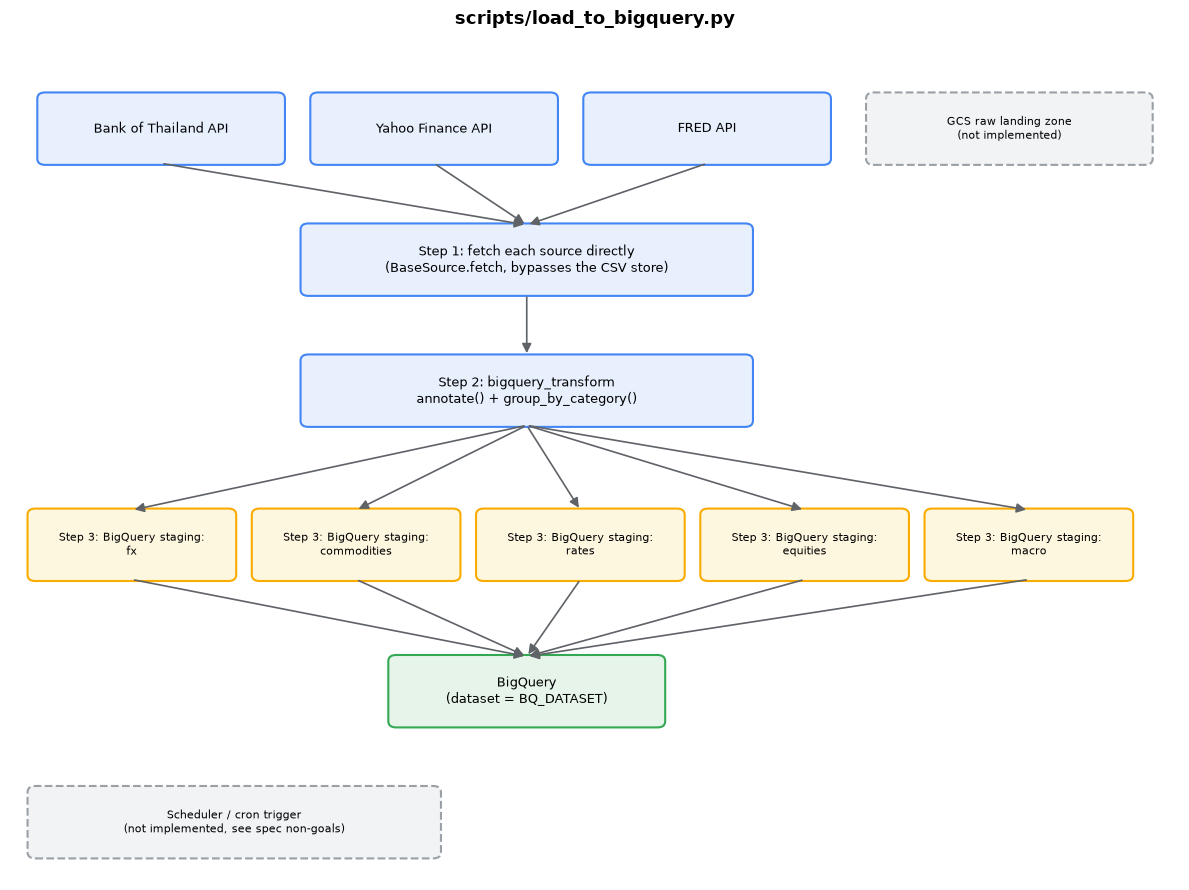

In [2]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def draw_box(ax, x, y, w, h, text, fc="#e8f0fe", ec="#4285f4", ls="-", fontsize=9):
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            fc=fc, ec=ec, lw=1.5, linestyle=ls,
        )
    )
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def draw_arrow(ax, start, end):
    ax.add_patch(
        FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, color="#5f6368", lw=1.2)
    )


fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis("off")
ax.set_title("scripts/load_to_bigquery.py", fontsize=13, fontweight="bold")

# sources -- Step 1: get the data
draw_box(ax, 0.3, 9.3, 2.5, 0.9, "Bank of Thailand API")
draw_box(ax, 3.1, 9.3, 2.5, 0.9, "Yahoo Finance API")
draw_box(ax, 5.9, 9.3, 2.5, 0.9, "FRED API")
draw_box(ax, 8.8, 9.3, 2.9, 0.9, "GCS raw landing zone\n(not implemented)", fc="#f1f3f4", ec="#9aa0a6", ls="--", fontsize=8)

draw_box(ax, 3.0, 7.6, 4.6, 0.9, "Step 1: fetch each source directly\n(BaseSource.fetch, bypasses the CSV store)")
for sx in (1.55, 4.35, 7.15):
    draw_arrow(ax, (sx, 9.3), (5.3, 8.5))

# Step 2: transform
draw_box(ax, 3.0, 5.9, 4.6, 0.9, "Step 2: bigquery_transform\nannotate() + group_by_category()")
draw_arrow(ax, (5.3, 7.6), (5.3, 6.8))

# Step 3: push -- category staging tables
categories = ["fx", "commodities", "rates", "equities", "macro"]
cat_x = [0.2, 2.5, 4.8, 7.1, 9.4]
for x, cat_name in zip(cat_x, categories):
    draw_box(ax, x, 3.9, 2.1, 0.9, f"Step 3: BigQuery staging:\n{cat_name}", fc="#fef7e0", ec="#f9ab00", fontsize=8)
    draw_arrow(ax, (5.3, 5.9), (x + 1.05, 4.8))

# bigquery dataset
draw_box(ax, 3.9, 2.0, 2.8, 0.9, "BigQuery\n(dataset = BQ_DATASET)", fc="#e6f4ea", ec="#34a853")
for x in cat_x:
    draw_arrow(ax, (x + 1.05, 3.9), (5.3, 2.9))

# scheduler non-goal
draw_box(ax, 0.2, 0.3, 4.2, 0.9, "Scheduler / cron trigger\n(not implemented, see spec non-goals)", fc="#f1f3f4", ec="#9aa0a6", ls="--", fontsize=8)

plt.tight_layout()
plt.show()

## 2. Category mapping

Every series in scope (`source` in `{bot, yahoo, fred}`) is mapped to one of
five categories in `scripts/bigquery_categories.py` -- a plain dict, not a
`catalog.yaml` field. `category_for()` raises `KeyError` for an unmapped id
rather than silently skipping it, so a new catalog series can't fall out of
the BigQuery loader unnoticed.

In [3]:
category_df = (
    pd.Series(CATEGORY_BY_SERIES, name="category")
    .rename_axis("series_id")
    .reset_index()
    .sort_values(["category", "series_id"])
    .reset_index(drop=True)
)
category_df

,series_id,category
0,brent_oil,commodities
1,copper_usd,commodities
2,gold_usd,commodities
3,natural_gas,commodities
4,silver_usd,commodities
5,wti_oil,commodities
6,set_index,equities
7,sp500,equities
8,eur_thb,fx
9,eur_usd,fx


In [4]:
try:
    category_for("not_a_real_series")
except KeyError as exc:
    print(f"KeyError: {exc}")

KeyError: "no BigQuery category mapped for series 'not_a_real_series' (add it to CATEGORY_BY_SERIES in bigquery_categories.py)"


## 3. Step 1: get the data from the sources

This is the step the diagram's `Bank of Thailand API` / `Yahoo Finance API` /
`FRED API` boxes feed into. For every catalog series whose `source` is in
scope, call that source's `fetch(cfg, start=None)` directly -- the exact
same `BaseSource` classes the CSV pipeline uses, just called straight from
here instead of through `macro_data.update_all()`. Nothing is transformed or
pushed anywhere yet; the result of this cell is the raw `(date, value)`
frame for every series that fetched successfully, plus a per-series status
for the ones that didn't.

In [5]:
in_scope = [c for c in load_catalog(Path("..") / "catalog.yaml") if c.source in load_to_bigquery.SOURCES]
print(f"{len(in_scope)} series in scope (source in {sorted(load_to_bigquery.SOURCES)})")

fetch_status = {}
raw_frames = {}  # series_id -> raw (date, value) DataFrame, straight from the source
source_instances = {}
for cfg in in_scope:
    try:
        if cfg.source not in source_instances:
            source_instances[cfg.source] = load_to_bigquery.SOURCES[cfg.source]()
        raw = source_instances[cfg.source].fetch(cfg, start=None)
        raw_frames[cfg.id] = raw
        fetch_status[cfg.id] = f"fetched ({len(raw)} rows)"
    except Exception as exc:  # noqa: BLE001 - one bad series must not stop the rest
        fetch_status[cfg.id] = f"failed: {exc}"

pd.Series(fetch_status, name="status").to_frame()

21 series in scope (source in ['bot', 'fred', 'yahoo'])


,status
usd_thb,fetched (5873 rows)
eur_usd,fetched (5874 rows)
gold_usd,fetched (6496 rows)
brent_oil,fetched (4723 rows)
wti_oil,fetched (6505 rows)
silver_usd,fetched (6498 rows)
copper_usd,fetched (6501 rows)
natural_gas,fetched (6502 rows)
sp500,fetched (24754 rows)
set_index,fetched (7219 rows)


That's the real output of hitting BOT/Yahoo/FRED right now. A couple of
sample raw frames, straight from the source, no BigQuery involvement at all
yet:

In [6]:
raw_frames["usd_thb"].tail()

,value
date,
2026-07-16,33.532001
2026-07-17,33.529999
2026-07-20,33.650002
2026-07-21,33.630001
2026-07-22,33.779999


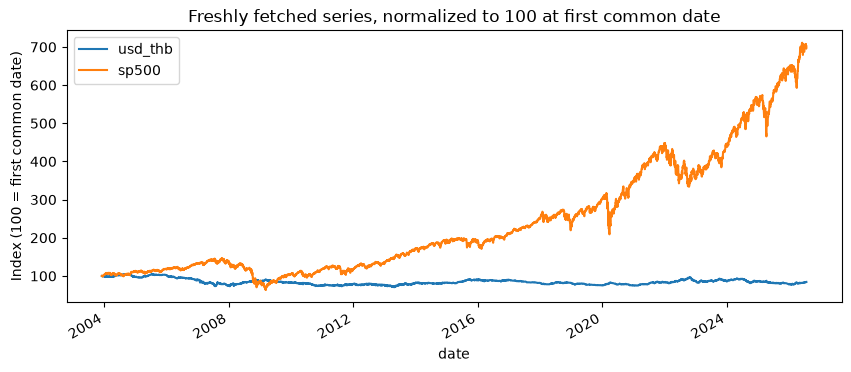

In [7]:
compare_ids = [sid for sid in ("usd_thb", "sp500") if sid in raw_frames]
combined = pd.DataFrame({sid: raw_frames[sid]["value"] for sid in compare_ids}).dropna()
normalized = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4))
normalized.plot(ax=ax, title="Freshly fetched series, normalized to 100 at first common date")
ax.set_ylabel("Index (100 = first common date)")
plt.show()

## 4. Step 2: transform into BigQuery-ready rows

`annotate()` is a pure function: it takes one of the raw frames just fetched
above and adds the metadata columns a BigQuery staging table needs
(`series_id`, `source`, `name`, `category`, `loaded_at`). First, a single
series in isolation so the shape is easy to see -- reusing the `usd_thb`
frame already fetched, no new network call:

In [8]:
usd_thb_cfg = next(c for c in in_scope if c.id == "usd_thb")
loaded_at_demo = pd.Timestamp.now(tz="UTC")
usd_thb_annotated = annotate(usd_thb_cfg, category_for(usd_thb_cfg.id), raw_frames["usd_thb"], loaded_at_demo)
usd_thb_annotated.tail()

,series_id,source,name,category,date,value,loaded_at
5868,usd_thb,yahoo,USD/THB exchange rate,fx,2026-07-16,33.532001,2026-07-22 05:26:03.542203+00:00
5869,usd_thb,yahoo,USD/THB exchange rate,fx,2026-07-17,33.529999,2026-07-22 05:26:03.542203+00:00
5870,usd_thb,yahoo,USD/THB exchange rate,fx,2026-07-20,33.650002,2026-07-22 05:26:03.542203+00:00
5871,usd_thb,yahoo,USD/THB exchange rate,fx,2026-07-21,33.630001,2026-07-22 05:26:03.542203+00:00
5872,usd_thb,yahoo,USD/THB exchange rate,fx,2026-07-22,33.779999,2026-07-22 05:26:03.542203+00:00


Now the same transform applied to every series fetched in Step 1, then
grouped into one frame per category with `group_by_category()`:

In [9]:
annotated_frames = [
    annotate(cfg, category_for(cfg.id), raw_frames[cfg.id], loaded_at_demo)
    for cfg in in_scope
    if cfg.id in raw_frames
]
by_category = group_by_category(annotated_frames)

for category, cat_df in sorted(by_category.items()):
    print(f"{category}: {len(cat_df)} rows")

commodities: 37225 rows
equities: 31973 rows
fx: 42742 rows
macro: 1817 rows
rates: 61251 rows


## 5. Step 3: push to BigQuery staging tables

Only now does anything BigQuery-shaped happen. `load_category_table()` is
the real function `load_to_bigquery.run()` calls per category; here it's
handed the frames built in Step 2 directly. Since this environment has no
`GCP_PROJECT`/`BQ_DATASET` configured, the `client` passed in is a small
stand-in that records what would be sent instead of making a network
call.

In [10]:
class DemoBigQueryClient:
    """Stand-in for google.cloud.bigquery.Client -- used only because this
    environment has no GCP_PROJECT/BQ_DATASET configured (see .env.example).
    Records what would be sent to BigQuery instead of making a network call;
    swap for a real bigquery.Client(project=...) to run this for real."""

    def __init__(self):
        self.loaded_tables = {}

    def load_table_from_dataframe(self, dataframe, destination, job_config=None):
        self.loaded_tables[destination] = dataframe.copy()
        return _DemoLoadJob()


class _DemoLoadJob:
    def result(self):
        return None


demo_client = DemoBigQueryClient()
load_status = {}
for category, cat_df in by_category.items():
    try:
        rows = load_category_table(demo_client, "demo-project", "demo_dataset", category, cat_df)
        load_status[category] = f"loaded ({rows} rows)"
    except Exception as exc:  # noqa: BLE001 - one bad table must not stop the rest
        load_status[category] = f"failed: {exc}"

pd.Series(load_status, name="status").to_frame()

,status
commodities,loaded (37225 rows)
equities,loaded (31973 rows)
fx,loaded (42742 rows)
macro,loaded (1817 rows)
rates,loaded (61251 rows)


## 6. Inspecting what was "loaded" into each staging table

`demo_client.loaded_tables` holds exactly the DataFrames that
`load_category_table()` handed to `bigquery.Client.load_table_from_dataframe()`
-- same columns, same `WRITE_TRUNCATE` semantics (every run replaces the
table's full contents).

In [11]:
for table_id, table_df in sorted(demo_client.loaded_tables.items()):
    print(f"{table_id}: {len(table_df)} rows")

demo-project.demo_dataset.commodities: 37225 rows
demo-project.demo_dataset.equities: 31973 rows
demo-project.demo_dataset.fx: 42742 rows
demo-project.demo_dataset.macro: 1817 rows
demo-project.demo_dataset.rates: 61251 rows


In [12]:
demo_client.loaded_tables["demo-project.demo_dataset.fx"].head()

,series_id,source,name,date,value,loaded_at
0,usd_thb,yahoo,USD/THB exchange rate,2003-12-01,39.889999,2026-07-22 05:26:03.542203+00:00
1,usd_thb,yahoo,USD/THB exchange rate,2003-12-02,39.848999,2026-07-22 05:26:03.542203+00:00
2,usd_thb,yahoo,USD/THB exchange rate,2003-12-03,39.806999,2026-07-22 05:26:03.542203+00:00
3,usd_thb,yahoo,USD/THB exchange rate,2003-12-04,39.869999,2026-07-22 05:26:03.542203+00:00
4,usd_thb,yahoo,USD/THB exchange rate,2003-12-05,39.813000,2026-07-22 05:26:03.542203+00:00


## 7. Error isolation

Two independent layers, both already exercised above without any extra
setup:

**Fetch-layer isolation** already happened for real in Step 1 -- any series
whose `fetch()` raised (for example BOT's older gateway, which is DNS-dead
as of 2026-07-15) shows up as `"failed: ..."` in `fetch_status` without
blocking any other series.

In [13]:
failed_series = {k: v for k, v in fetch_status.items() if v.startswith("failed:")}
failed_series or "(nothing failed on this run)"


{'usd_thb_bot': 'failed: HTTPSConnectionPool(host=\'apigw1.bot.or.th\', port=443): Max retries exceeded with url: /bot/public/Stat-ExchangeRate/v2/DAILY_AVG_EXG_RATE/?currency=USD&start_period=2000-01-01&end_period=2026-07-22 (Caused by NameResolutionError("HTTPSConnection(host=\'apigw1.bot.or.th\', port=443): Failed to resolve \'apigw1.bot.or.th\' ([Errno 11001] getaddrinfo failed)"))'}

**Load-layer isolation**: one category's BigQuery load raising never blocks
the others. Rather than re-fetching or re-transforming anything, this reuses
`by_category` from Step 2 with a client that fails on purpose for one
table.

In [14]:
class FlakyBigQueryClient:
    """Like DemoBigQueryClient, but simulates a BigQuery outage for one table."""

    def __init__(self, fail_categories):
        self._fail_categories = set(fail_categories)

    def load_table_from_dataframe(self, dataframe, destination, job_config=None):
        category = destination.rsplit(".", 1)[-1]
        if category in self._fail_categories:
            raise RuntimeError(f"simulated BigQuery outage for table {destination}")
        return _DemoLoadJob()


flaky_client = FlakyBigQueryClient(fail_categories={"rates"})
isolated_load_status = {}
for category, cat_df in by_category.items():
    try:
        rows = load_category_table(flaky_client, "demo-project", "demo_dataset", category, cat_df)
        isolated_load_status[category] = f"loaded ({rows} rows)"
    except Exception as exc:  # noqa: BLE001 - same isolation contract as load_to_bigquery.run()
        isolated_load_status[category] = f"failed: {exc}"

pd.Series(isolated_load_status, name="status").to_frame()

,status
commodities,loaded (37225 rows)
equities,loaded (31973 rows)
fx,loaded (42742 rows)
macro,loaded (1817 rows)
rates,failed: simulated BigQuery outage for table de...


## 8. Running this against a real BigQuery project

Steps 1-3 above are exactly what `load_to_bigquery.run()` does in one call
-- it's the same fetch loop, the same `annotate()`/`group_by_category()`,
and the same `load_category_table()` calls, just packaged into a single
function instead of separated out cell-by-cell for inspection:

1. `uv pip install -e ".[bigquery]"` to install `google-cloud-bigquery` and `pyarrow`.
2. Set `GCP_PROJECT` and `BQ_DATASET` in `.env` (see `.env.example`), and make
   sure Application Default Credentials are available (for example
   `gcloud auth application-default login`, or point
   `GOOGLE_APPLICATION_CREDENTIALS` at a service account key).
3. Run `python scripts/load_to_bigquery.py` from the project root, or call
   `load_to_bigquery.run()` with no `client=` override -- it constructs a real
   `bigquery.Client(project=...)` and truncate-reloads each category table for
   real.

Only the stand-in `DemoBigQueryClient`/`FlakyBigQueryClient` used in this
notebook get swapped out for the real thing; every fetch, transform, and
category-mapping step demonstrated above is unchanged.